In [3]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
RANDOM_STATE = 42 


In [2]:
df = pd.read_csv("garments_worker_productivity.csv")

In [6]:
df = pd.DataFrame(df)


In [7]:
df

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [9]:
df["department"].unique()

array(['sweing', 'finishing ', 'finishing'], dtype=object)

In [10]:
df["department"] = df["department"].str.strip()

In [ ]:
df["department"].unique()

array(['sweing', 'finishing'], dtype=object)

In [20]:
df["department"].value_counts()

department
sweing       691
finishing    506
Name: count, dtype: int64

In [24]:
df[df["department"]=="finishing"]["wip"]

1      NaN
6      NaN
13     NaN
14     NaN
15     NaN
        ..
1192   NaN
1193   NaN
1194   NaN
1195   NaN
1196   NaN
Name: wip, Length: 506, dtype: float64

In [12]:
df = df.drop(columns=["date"])

In [13]:
print(df.isnull().sum())

quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


In [14]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [15]:
df["actual_productivity"] = df["actual_productivity"].clip(upper=1.0)

In [16]:
df["MeetsTarget"] = (df["actual_productivity"] >= df["targeted_productivity"]).astype(int)

df["MeetsTarget"].value_counts(normalize=True)

MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64

In [17]:
df.groupby("department")["wip"].apply(lambda s: s.isna().mean())

department
finishing    1.0
sweing       0.0
Name: wip, dtype: float64

In [25]:
df["team"] = df["team"].astype(str)
train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df["MeetsTarget"]
)
train_df, test_df = df.loc[train_idx], df.loc[test_idx]

In [26]:
cat_cols = ["quarter", "department", "day", "team"]
num_cols = ["targeted_productivity", "smv", "wip", "over_time", "incentive",
            "idle_time", "idle_men", "no_of_style_change", "no_of_workers"]

X_train, X_test = train_df[cat_cols + num_cols], test_df[cat_cols + num_cols]
y_reg_train,  y_reg_test  = train_df["actual_productivity"], test_df["actual_productivity"]
y_clf_train,  y_clf_test  = train_df["MeetsTarget"],         test_df["MeetsTarget"]

In [27]:
num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc",  StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("ohe", OneHotEncoder(drop="first"))])

preprocess = ColumnTransformer([("num", num_pipe, num_cols),
                                ("cat", cat_pipe, cat_cols)],
                               sparse_threshold=0)   

In [30]:
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

In [31]:
# --- Warm-up call (not timed) ---
_ = LinearRegression().fit(X_train_processed, y_reg_train)

# --- Actual timed runs, averaged ---
n_trials = 10
train_times = []
predict_times = []

for _ in range(n_trials):
    lin_model = LinearRegression()

    t0 = time.perf_counter()
    lin_model.fit(X_train_processed, y_reg_train)
    train_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    y_pred_reg = lin_model.predict(X_test_processed)
    predict_times.append(time.perf_counter() - t0)

train_time_reg = np.median(train_times)
predict_time_reg = np.median(predict_times)

print(f"train_time_reg={train_time_reg:.6f}s  predict_time_reg={predict_time_reg:.6f}s")

train_time_reg=0.004575s  predict_time_reg=0.000332s


In [32]:
mae = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2 = r2_score(y_reg_test, y_pred_reg)

print(f"MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
print(f"train_time={train_time_reg:.6f}s  predict_time={predict_time_reg:.6f}s")

MAE=0.1079  RMSE=0.1423  R2=0.2924
train_time=0.004575s  predict_time=0.000332s


In [34]:
# --- Warm-up call (not timed) ---
_ = LogisticRegression(max_iter=1000).fit(X_train_processed, y_clf_train)

# --- Actual timed runs, averaged ---
train_times, predict_times = [], []
for _ in range(n_trials):
    log_model = LogisticRegression(max_iter=1000)

    t0 = time.perf_counter()
    log_model.fit(X_train_processed,y_clf_train)
    train_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    y_pred_clf = log_model.predict(X_test_processed)
    predict_times.append(time.perf_counter() - t0)

train_time_clf = np.median(train_times)
predict_time_clf = np.median(predict_times)

print(f"train_time_clf={train_time_clf:.6f}s  predict_time_clf={predict_time_clf:.6f}s")

train_time_clf=0.019450s  predict_time_clf=0.000451s


In [35]:
acc = accuracy_score(y_clf_test, y_pred_clf)
prec = precision_score(y_clf_test, y_pred_clf)
rec = recall_score(y_clf_test, y_pred_clf)     
f1 = f1_score(y_clf_test, y_pred_clf)

print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
print(f"train_time={train_time_clf:.6f}s  predict_time={predict_time_clf:.6f}s")

Accuracy=0.6833  Precision=0.7619  Recall=0.8229  F1=0.7912
train_time=0.019450s  predict_time=0.000451s


In [37]:
results_sklearn = {
    "regression": {"MAE": mae, "RMSE": rmse, "R2": r2,
                   "train_time": train_time_reg, "predict_time": predict_time_reg},
    "classification": {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1,
                        "train_time": train_time_clf, "predict_time": predict_time_clf}
}
results_sklearn

{'regression': {'MAE': 0.107914648947417,
  'RMSE': np.float64(0.14225417456270387),
  'R2': 0.29237156939049447,
  'train_time': np.float64(0.004575300001306459),
  'predict_time': np.float64(0.0003317499649710953)},
 'classification': {'Accuracy': 0.6833333333333333,
  'Precision': 0.7619047619047619,
  'Recall': 0.8228571428571428,
  'F1': 0.7912087912087912,
  'train_time': np.float64(0.019450000021606684),
  'predict_time': np.float64(0.0004506499972194433)}}

# PART B

In [38]:
# Compute median from TRAIN only
wip_median = train_df["wip"].median()

# Copy so the original data remains unchanged
train_df = train_df.copy()
test_df = test_df.copy()

# Apply TRAIN median to both train and test
train_df["wip"] = train_df["wip"].fillna(wip_median)
test_df["wip"] = test_df["wip"].fillna(wip_median)

In [39]:
X_train = train_df[cat_cols + num_cols].copy()
X_test = test_df[cat_cols + num_cols].copy()

In [40]:
# Compute categorical modes from TRAIN only
cat_modes = train_df[cat_cols].mode().iloc[0]

# Fill missing categorical values using TRAIN modes
for col in cat_cols:
    X_train[col] = X_train[col].fillna(cat_modes[col])
    X_test[col] = X_test[col].fillna(cat_modes[col])

In [41]:
train_ohe = pd.get_dummies(X_train[cat_cols], columns=cat_cols, drop_first=True)

test_ohe = (pd.get_dummies(X_test[cat_cols], columns=cat_cols)
              .reindex(columns=train_ohe.columns, fill_value=0))

In [42]:
test_ohe = test_ohe.reindex(
    columns=train_ohe.columns,
    fill_value=0
)

In [43]:
X_train_manual = pd.concat(
    [
        X_train[num_cols],
        train_ohe
    ],
    axis=1
)

X_test_manual = pd.concat(
    [
        X_test[num_cols],
        test_ohe
    ],
    axis=1
)

In [44]:
print(X_train_manual.shape)
print(X_test_manual.shape)

(957, 30)
(240, 30)


In [45]:
train_num = X_train_manual[num_cols]
test_num = X_test_manual[num_cols]

In [46]:
# Learn scaling parameters from TRAIN only
mu = train_num.mean()
sigma = train_num.std(ddof=0)

# Prevent division by zero for any constant feature
sigma = sigma.replace(0, 1)

we use ddof = 0 as Scikit learn uses n in denominator instead of n-1.

In [47]:
train_num_scaled = (train_num - mu) / sigma
test_num_scaled = (test_num - mu) / sigma

In [48]:
X_train_manual = pd.concat(
    [train_num_scaled, train_ohe],
    axis=1
).astype(float)

X_test_manual = pd.concat(
    [test_num_scaled, test_ohe],
    axis=1
).astype(float)

In [49]:
print("Train shape:", X_train_manual.shape)
print("Test shape :", X_test_manual.shape)

Train shape: (957, 30)
Test shape : (240, 30)


In [50]:
y_train_reg = train_df["actual_productivity"].values
y_test_reg = test_df["actual_productivity"].values

y_train_clf = train_df["MeetsTarget"].values
y_test_clf = test_df["MeetsTarget"].values

Linear Regression

In [51]:
def add_intercept(X):
    return np.hstack([
        np.ones((X.shape[0], 1)),
        X.to_numpy()
    ])

X_train_reg = add_intercept(X_train_manual)
X_test_reg = add_intercept(X_test_manual)

In [52]:
def median_time(fn, n_trials=10):
    fn()                                                  # warm-up (untimed)
    ts = []
    for _ in range(n_trials):
        t0 = time.perf_counter(); out = fn(); ts.append(time.perf_counter() - t0)
    return np.median(ts), out

# X^T X = X_train_reg.T @ X_train_reg
# X^T y = X_train_reg.T @ y_train_reg

linear_train_time,   beta_reg      = median_time(lambda: np.linalg.solve(X_train_reg.T @ X_train_reg,
                                                                         X_train_reg.T @ y_train_reg))
linear_predict_time, y_pred_reg_np = median_time(lambda: X_test_reg @ beta_reg)

In [53]:
print("Intercept:", beta_reg[0])
print("Number of coefficients:", len(beta_reg) - 1)

Intercept: 0.8251749871418248
Number of coefficients: 30


In [54]:
maeB  = np.mean(np.abs(y_test_reg - y_pred_reg_np))
rmseB = np.sqrt(np.mean((y_test_reg - y_pred_reg_np) ** 2))
r2B   = 1 - np.sum((y_test_reg - y_pred_reg_np) ** 2) / np.sum((y_test_reg - np.mean(y_test_reg)) ** 2)

In [55]:
print(np.allclose(beta_reg[1:], lin_model.coef_), np.isclose(beta_reg[0], lin_model.intercept_))
print(f"MAE={maeB:.4f}  RMSE={rmseB:.4f}  R2={r2B:.4f}")

True True
MAE=0.1079  RMSE=0.1423  R2=0.2924


In [56]:
print("Manual Linear Regression")
print("------------------------")
print(f"MAE             : {maeB:.4f}")
print(f"RMSE            : {rmseB:.4f}")
print(f"R²              : {r2B:.4f}")
print(f"Training time   : {linear_train_time:.6f} s")
print(f"Prediction time : {linear_predict_time:.6f} s")

Manual Linear Regression
------------------------
MAE             : 0.1079
RMSE            : 0.1423
R²              : 0.2924
Training time   : 0.000191 s
Prediction time : 0.000005 s


Logistic Regression

In [57]:
X_train_clf = add_intercept(X_train_manual)
X_test_clf = add_intercept(X_test_manual)

In [58]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))          

def predict_clf(X, beta, thr=0.5):
    return (sigmoid(X @ beta) >= thr).astype(int)

In [59]:
def fit_logistic(X, y, lr=1.0, n_iter=20000, tol=1e-7):
    n = len(y)
    eta = lr / n                                  # sum-gradient -> scale by 1/n (about your 0.001)
    beta = np.zeros(X.shape[1])                   # fresh start on every call
    for i in range(n_iter):
        z = X @ beta                              # Step 1: z = Xβ
        p = sigmoid(z)                            # Step 2: p = σ(z)
        gradient = X.T @ (p - y)                  # Step 3: Xᵀ(p − y)
        beta = beta - eta * gradient              # Step 4: β ← β − η · gradient
        if np.abs(gradient).max() / n < tol:      # stop when Xᵀ(p − y) ≈ 0
            break
    return beta, i + 1

logistic_train_time, (beta_clf, n_iter_used) = median_time(
    lambda: fit_logistic(X_train_clf, y_train_clf))

In [60]:
logistic_predict_time, y_pred_clf_np = median_time(lambda: predict_clf(X_test_clf, beta_clf))
print("iterations:", n_iter_used, "| train:", logistic_train_time, "| predict:", logistic_predict_time)

iterations: 11917 | train: 0.6619762500049546 | predict: 3.5950040910393e-05


In [61]:
def bce(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)                       # avoid log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

p_train = sigmoid(X_train_clf @ beta_clf)
p_test  = sigmoid(X_test_clf  @ beta_clf)

print("train BCE :", bce(y_train_clf, p_train))
print("test  BCE :", bce(y_test_clf,  p_test))
print("baseline  :", bce(y_train_clf, np.full(len(y_train_clf), y_train_clf.mean())))
print("sklearn train BCE:", bce(y_train_clf, log_model.predict_proba(X_train_processed)[:, 1]))

train BCE : 0.46072528951171565
test  BCE : 0.5578812324263429
baseline  : 0.5818088372748405
sklearn train BCE: 0.46271970226197245


In [62]:
def fit_logistic_tracked(X, y, lr=1.0, n_iter=20000, tol=1e-7, every=10):
    n = len(y); eta = lr / n
    beta = np.zeros(X.shape[1])
    iters, losses, gnorms = [], [], []
    for i in range(n_iter):
        p = sigmoid(X @ beta)
        gradient = X.T @ (p - y)
        g = np.abs(gradient).max() / n                 # size of Xᵀ(p−y)/n
        if i % every == 0:                             # record every 10 steps
            iters.append(i); losses.append(bce(y, p)); gnorms.append(g)
        beta = beta - eta * gradient                   # same update as fit_logistic
        if g < tol: break
    return beta, np.array(iters), np.array(losses), np.array(gnorms), i + 1

beta_tr, iters, losses, gnorms, n_used = fit_logistic_tracked(X_train_clf, y_train_clf)

print("iterations:", n_used, "(timed run used", n_iter_used, ")")
print("same beta as timed run:", np.allclose(beta_tr, beta_clf, atol=1e-4))
print("loss  first / mid / last:", losses[0].round(4), losses[len(losses)//2].round(4), losses[-1].round(5))
print("final max|grad|:", gnorms[-1])

iterations: 11917 (timed run used 11917 )
same beta as timed run: True
loss  first / mid / last: 0.6931 0.4607 0.46073
final max|grad|: 1.0036971612556389e-07


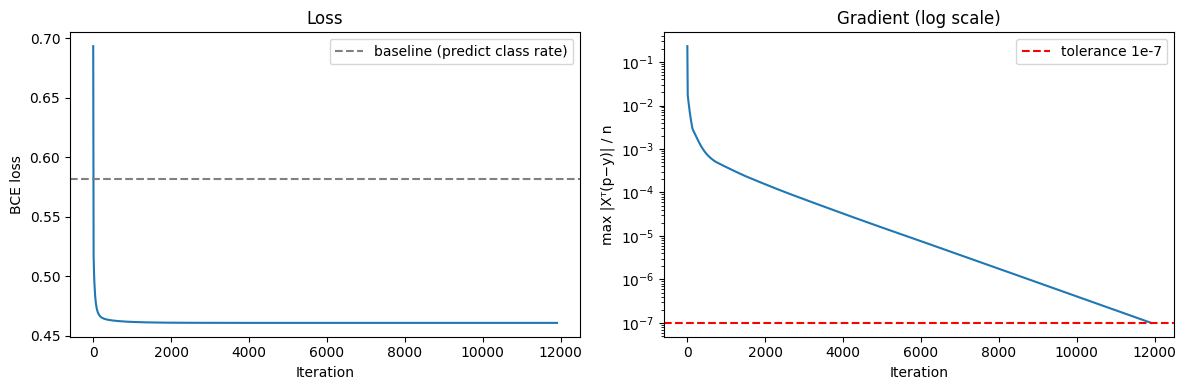

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(iters, losses)
ax[0].axhline(bce(y_train_clf, np.full(len(y_train_clf), y_train_clf.mean())),
              ls="--", color="gray", label="baseline (predict class rate)")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("BCE loss"); ax[0].set_title("Loss"); ax[0].legend()

ax[1].semilogy(iters, gnorms)
ax[1].axhline(1e-7, ls="--", color="red", label="tolerance 1e-7")
ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("max |Xᵀ(p−y)| / n"); ax[1].set_title("Gradient (log scale)"); ax[1].legend()

plt.tight_layout(); plt.show()

In [64]:
tp = np.sum((y_test_clf == 1) & (y_pred_clf_np == 1))
tn = np.sum((y_test_clf == 0) & (y_pred_clf_np == 0))
fp = np.sum((y_test_clf == 0) & (y_pred_clf_np == 1))
fn = np.sum((y_test_clf == 1) & (y_pred_clf_np == 0))

accB  = (tp + tn) / len(y_test_clf)
precB = tp / (tp + fp) if (tp + fp) else 0.0          # of predicted "meets target", how many truly did
recB  = tp / (tp + fn) if (tp + fn) else 0.0          # of true "meets target", how many we caught
f1B   = 2 * precB * recB / (precB + recB) if (precB + recB) else 0.0

print(f"Accuracy={accB:.4f}  Precision={precB:.4f}  Recall={recB:.4f}  F1={f1B:.4f}")
print("Confusion matrix [[TN FP] [FN TP]]:", [[tn, fp], [fn, tp]])

Accuracy=0.6875  Precision=0.7688  Recall=0.8171  F1=0.7922
Confusion matrix [[TN FP] [FN TP]]: [[np.int64(22), np.int64(43)], [np.int64(32), np.int64(143)]]


In [65]:
results_scratch = {
    "regression": {"MAE": maeB, "RMSE": rmseB, "R2": r2B,
                   "train_time": linear_train_time, "predict_time": linear_predict_time},
    "classification": {"Accuracy": accB, "Precision": precB,
                       "Recall": recB, "F1": f1B,
                       "train_time": logistic_train_time, "predict_time": logistic_predict_time}
}
results_scratch

{'regression': {'MAE': np.float64(0.10791464894741683),
  'RMSE': np.float64(0.14225417456270378),
  'R2': np.float64(0.29237156939049525),
  'train_time': np.float64(0.0001910499995574355),
  'predict_time': np.float64(4.599976819008589e-06)},
 'classification': {'Accuracy': np.float64(0.6875),
  'Precision': np.float64(0.7688172043010753),
  'Recall': np.float64(0.8171428571428572),
  'F1': np.float64(0.7922437673130194),
  'train_time': np.float64(0.6619762500049546),
  'predict_time': np.float64(3.5950040910393e-05)}}

In [66]:
rows = []
for task in ["regression", "classification"]:
    for metric, sk_val in results_sklearn[task].items():
        sc_val = results_scratch[task][metric]
        diff   = sc_val - sk_val
        rows.append({"Task": task.capitalize(), "Metric": metric,
                     "Scikit-learn": sk_val, "From Scratch": sc_val,
                     "Diff (Scratch - Sklearn)": diff,
                     "% Diff": diff / sk_val * 100 if sk_val != 0 else np.nan})

comparison = pd.DataFrame(rows)
comparison

,Task,Metric,Scikit-learn,From Scratch,Diff (Scratch - Sklearn),% Diff
0,Regression,MAE,0.107915,0.107915,-1.665335e-16,-1.543196e-13
1,Regression,RMSE,0.142254,0.142254,-8.326673e-17,-5.853377e-14
2,Regression,R2,0.292372,0.292372,7.771561e-16,2.658111e-13
3,Regression,train_time,0.004575,0.000191,-4.384250e-03,-9.582432e+01
4,Regression,predict_time,0.000332,0.000005,-3.271500e-04,-9.861342e+01
5,Classification,Accuracy,0.683333,0.687500,4.166667e-03,6.097561e-01
6,Classification,Precision,0.761905,0.768817,6.912442e-03,9.072581e-01
7,Classification,Recall,0.822857,0.817143,-5.714286e-03,-6.944444e-01
8,Classification,F1,0.791209,0.792244,1.034976e-03,1.308095e-01
9,Classification,train_time,0.019450,0.661976,6.425262e-01,3.303477e+03


In [67]:
results_scratch = {t: {k: float(v) for k, v in d.items()} for t, d in results_scratch.items()}
results_scratch

{'regression': {'MAE': 0.10791464894741683,
  'RMSE': 0.14225417456270378,
  'R2': 0.29237156939049525,
  'train_time': 0.0001910499995574355,
  'predict_time': 4.599976819008589e-06},
 'classification': {'Accuracy': 0.6875,
  'Precision': 0.7688172043010753,
  'Recall': 0.8171428571428572,
  'F1': 0.7922437673130194,
  'train_time': 0.6619762500049546,
  'predict_time': 3.5950040910393e-05}}

In [68]:
# --- Table 1: predictive metrics ---
rows = []
for task in ["regression", "classification"]:
    for m in results_sklearn[task]:
        if m.endswith("_time"): continue
        sk, sc = float(results_sklearn[task][m]), results_scratch[task][m]
        rows.append({"Task": task.capitalize(), "Metric": m, "Scikit-learn": sk,
                     "From Scratch": sc, "Diff": sc - sk})
metrics_tbl = pd.DataFrame(rows)
display(metrics_tbl.style.format({"Scikit-learn": "{:.4f}", "From Scratch": "{:.4f}", "Diff": "{:+.4f}"})
                         .hide(axis="index"))

# --- Table 2: timing, with speed ratios ---
rows = []
for task in ["regression", "classification"]:
    for m in ["train_time", "predict_time"]:
        sk, sc = float(results_sklearn[task][m]), results_scratch[task][m]
        rows.append({"Task": task.capitalize(), "Stage": m.replace("_time", ""),
                     "Scikit-learn (ms)": sk * 1e3, "From Scratch (ms)": sc * 1e3,
                     "Scratch vs sklearn": (f"{sk/sc:.1f}× faster" if sc < sk else f"{sc/sk:.1f}× slower")})
display(pd.DataFrame(rows).style.format({"Scikit-learn (ms)": "{:.3f}", "From Scratch (ms)": "{:.3f}"})
                                .hide(axis="index"))

Task,Metric,Scikit-learn,From Scratch,Diff
Regression,MAE,0.1079,0.1079,-0.0000
Regression,RMSE,0.1423,0.1423,-0.0000
Regression,R2,0.2924,0.2924,+0.0000
Classification,Accuracy,0.6833,0.6875,+0.0042
Classification,Precision,0.7619,0.7688,+0.0069
Classification,Recall,0.8229,0.8171,-0.0057
Classification,F1,0.7912,0.7922,+0.0010


Task,Stage,Scikit-learn (ms),From Scratch (ms),Scratch vs sklearn
Regression,train,4.575,0.191,23.9× faster
Regression,predict,0.332,0.005,72.1× faster
Classification,train,19.450,661.976,34.0× slower
Classification,predict,0.451,0.036,12.5× faster


# PART C

In [69]:
corr = train_df[num_cols].corr()

corr.round(3)

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers
targeted_productivity,1.000,-0.063,0.041,-0.088,0.031,-0.059,-0.058,-0.214,-0.083
smv,-0.063,1.000,0.018,0.683,0.055,0.062,0.109,0.316,0.915
wip,0.041,0.018,1.000,0.048,0.035,-0.029,-0.052,-0.056,0.052
over_time,-0.088,0.683,0.048,1.000,0.015,0.035,-0.017,0.055,0.744
incentive,0.031,0.055,0.035,0.015,1.000,-0.016,-0.026,-0.028,0.068
idle_time,-0.059,0.062,-0.029,0.035,-0.016,1.000,0.590,-0.014,0.064
idle_men,-0.058,0.109,-0.052,-0.017,-0.026,0.590,1.000,0.123,0.107
no_of_style_change,-0.214,0.316,-0.056,0.055,-0.028,-0.014,0.123,1.000,0.330
no_of_workers,-0.083,0.915,0.052,0.744,0.068,0.064,0.107,0.330,1.000


In [70]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
)

corr_pairs

smv                    no_of_workers         0.914552
over_time              no_of_workers         0.743630
smv                    over_time             0.683361
idle_time              idle_men              0.589624
no_of_style_change     no_of_workers         0.329823
smv                    no_of_style_change    0.316296
targeted_productivity  no_of_style_change   -0.213525
idle_men               no_of_style_change    0.123087
smv                    idle_men              0.108901
idle_men               no_of_workers         0.106766
targeted_productivity  over_time            -0.088154
                       no_of_workers        -0.083488
incentive              no_of_workers         0.068425
idle_time              no_of_workers         0.063812
targeted_productivity  smv                  -0.063435
smv                    idle_time             0.062435
targeted_productivity  idle_time            -0.058546
                       idle_men             -0.057854
wip                    no_of

In [75]:
# Pearson correlation
corr = train_df[num_cols].corr()

# Spearman correlation = Pearson correlation of ranks
spearman = train_df[num_cols].rank().corr()

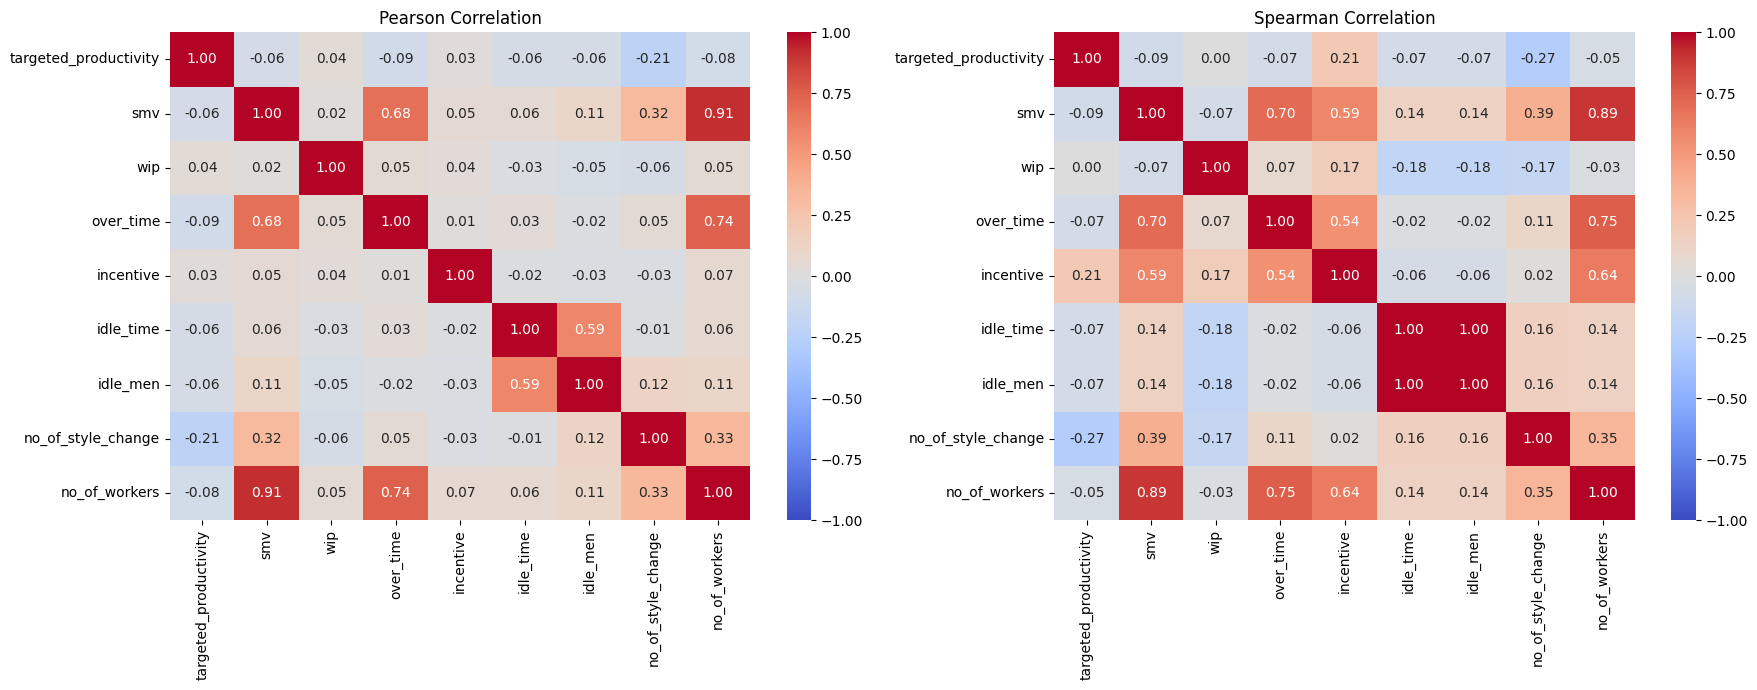

In [ ]:
tgt = pd.DataFrame({
    "pearson_reg":  train_df[num_cols].corrwith(train_df["actual_productivity"]),
    "spearman_reg": train_df[num_cols].rank().corrwith(train_df["actual_productivity"].rank()),
    "pearson_clf":  train_df[num_cols].corrwith(train_df["MeetsTarget"]),
}).round(3)

display(tgt.sort_values("pearson_reg", key=abs, ascending=False))

tgt.plot(kind="barh", figsize=(9, 6))
plt.title("Feature correlation with targets (train)")
plt.axvline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

,pearson_reg,spearman_reg,pearson_clf
targeted_productivity,0.417,0.442,-0.022
no_of_style_change,-0.209,-0.270,0.005
idle_men,-0.183,-0.149,-0.145
smv,-0.124,-0.125,0.150
idle_time,-0.088,-0.149,-0.064
wip,0.087,0.160,0.071
incentive,0.081,0.223,0.086
no_of_workers,-0.061,-0.040,0.245
over_time,-0.053,-0.075,0.210


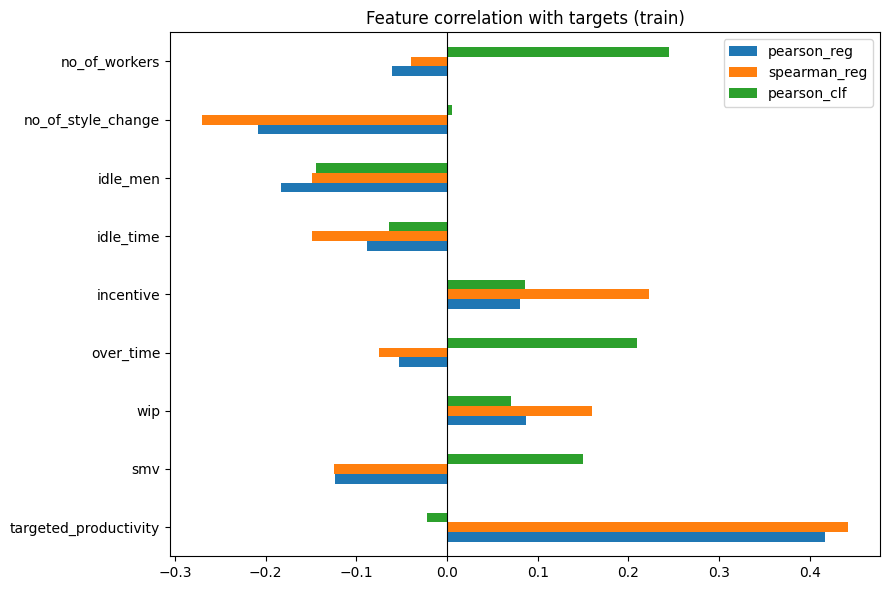

In [78]:

tgt = pd.DataFrame({
    "pearson_reg":  train_df[num_cols].corrwith(train_df["actual_productivity"]),
    "spearman_reg": train_df[num_cols].rank().corrwith(train_df["actual_productivity"].rank()),
    "pearson_clf":  train_df[num_cols].corrwith(train_df["MeetsTarget"]),
}).round(3)

display(tgt.sort_values("pearson_reg", key=abs, ascending=False))

tgt.plot(kind="barh", figsize=(9, 6))
plt.title("Feature correlation with targets (train)")
plt.axvline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

In [79]:
# Skewness of numeric features (train only) - tells us which columns need log1p
print(train_df[num_cols].skew().sort_values(key=abs, ascending=False).round(2))

# Working copies for feature engineering (no winsorising)
train_c = train_df.copy()
test_c  = test_df.copy()

idle_time                18.37
incentive                14.69
wip                      13.42
idle_men                  9.67
no_of_style_change        2.92
targeted_productivity    -2.08
over_time                 0.68
smv                       0.39
no_of_workers            -0.12
dtype: float64


In [80]:
skew_cols = ["wip", "incentive", "idle_time", "idle_men"]

def engineer(d):
    d = d.copy()
    w = d["no_of_workers"].clip(lower=1)                 # avoid divide-by-zero

    # ratios (computed on raw values, before log)
    d["over_time_per_worker"] = d["over_time"] / w
    d["wip_per_worker"]       = d["wip"] / w
    d["incentive_per_worker"] = d["incentive"] / w
    d["workload"]             = d["smv"] * w             # total standard minutes of work

    # binary flags
    d["has_incentive"]    = (d["incentive"] > 0).astype(float)
    d["has_idle"]         = (d["idle_time"] > 0).astype(float)
    d["has_style_change"] = (d["no_of_style_change"] > 0).astype(float)

    # log1p for skewed columns and the skewed ratios
    for c in skew_cols + ["over_time_per_worker", "wip_per_worker", "incentive_per_worker"]:
        d[c] = np.log1p(d[c])
    return d

train_fe = engineer(train_c)
test_fe  = engineer(test_c)

eng_cols = ["over_time_per_worker", "wip_per_worker", "incentive_per_worker",
            "workload", "has_incentive", "has_idle", "has_style_change"]
num_all  = num_cols + eng_cols

print("Features before selection:", len(num_all))
print("NaNs in train_fe:", train_fe[num_all].isna().sum().sum(),
      "| NaNs in test_fe:", test_fe[num_all].isna().sum().sum())

Features before selection: 16
NaNs in train_fe: 0 | NaNs in test_fe: 0


,|r| reg,|r| clf
targeted_productivity,0.417,0.022
has_style_change,0.242,0.015
no_of_style_change,0.209,0.005
incentive,0.187,0.407
idle_men,0.184,0.140
incentive_per_worker,0.178,0.268
has_idle,0.176,0.132
wip,0.165,0.160
idle_time,0.154,0.101
has_incentive,0.137,0.411


weakly correlated, dropped: []
Final numeric features: ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'over_time_per_worker', 'wip_per_worker', 'incentive_per_worker', 'workload', 'has_incentive', 'has_idle', 'has_style_change']


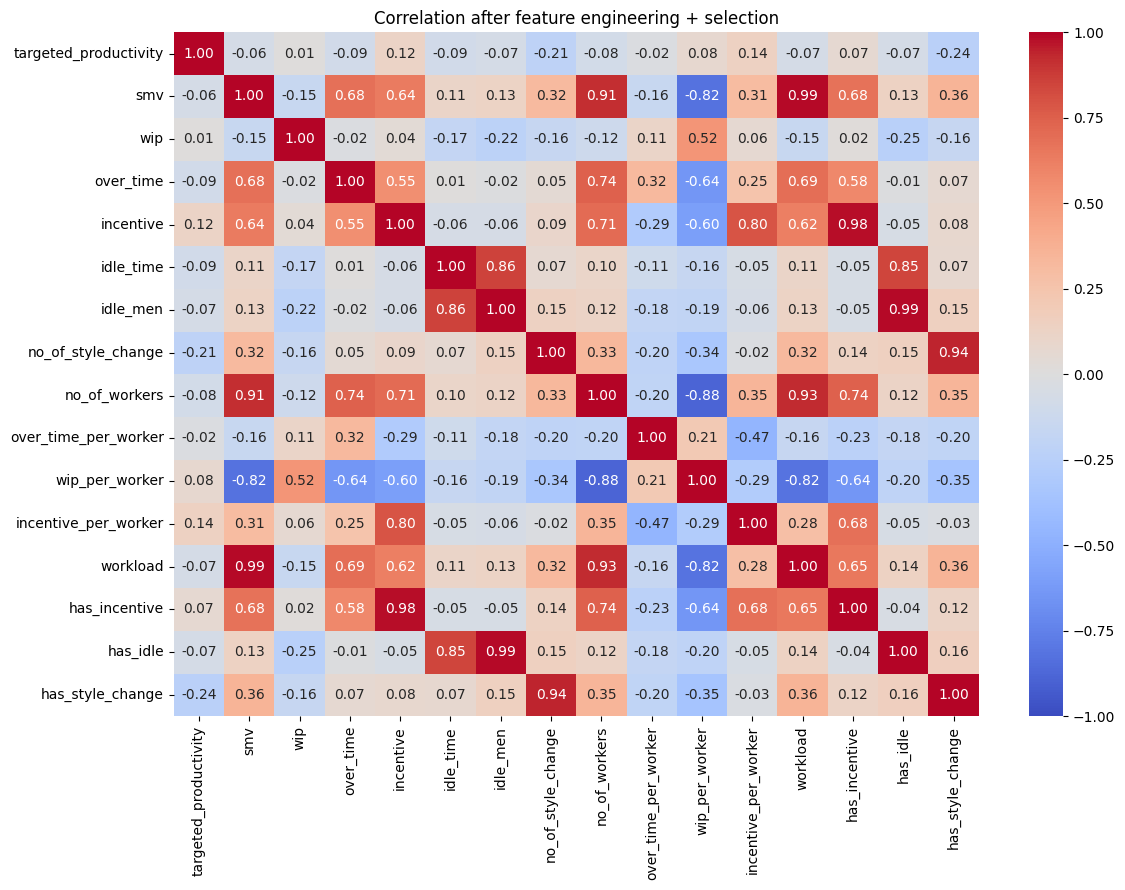

In [81]:
CORR_THR = 0.02

# Drop features weakly correlated with BOTH targets (train only)
r_reg = train_fe[num_all].corrwith(train_fe["actual_productivity"]).abs()
r_clf = train_fe[num_all].corrwith(train_fe["MeetsTarget"]).abs()

corr_table = pd.DataFrame({"|r| reg": r_reg, "|r| clf": r_clf}).round(3)
display(corr_table.sort_values("|r| reg", ascending=False))

weak = [c for c in num_all if r_reg[c] < CORR_THR and r_clf[c] < CORR_THR]
print("weakly correlated, dropped:", weak)

selected_num = [c for c in num_all if c not in weak]
print("Final numeric features:", selected_num)

plt.figure(figsize=(12, 9))
sns.heatmap(train_fe[selected_num].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation after feature engineering + selection")
plt.tight_layout(); plt.show()

In [82]:
PAIR_THR = 0.95

score = np.maximum(r_reg, r_clf)                       # strength of each feature vs either target
C = train_fe[selected_num].corr().abs()

cols, drop = list(selected_num), set()
for i, a in enumerate(cols):
    for b in cols[i + 1:]:
        if a in drop or b in drop:
            continue
        if C.loc[a, b] >= PAIR_THR:
            loser = a if score[a] < score[b] else b
            drop.add(loser)
            print(f"{a} vs {b}: r={C.loc[a, b]:.2f} -> drop {loser}")

selected_num = [c for c in cols if c not in drop]
print("\nFinal numeric features:", len(selected_num))
print(selected_num)

smv vs workload: r=0.99 -> drop workload
incentive vs has_incentive: r=0.98 -> drop incentive
idle_men vs has_idle: r=0.99 -> drop has_idle

Final numeric features: 13
['targeted_productivity', 'smv', 'wip', 'over_time', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'over_time_per_worker', 'wip_per_worker', 'incentive_per_worker', 'has_incentive', 'has_style_change']


In [83]:
mu2 = train_fe[selected_num].mean()
sd2 = train_fe[selected_num].std(ddof=0).replace(0, 1)

Xtr_num = ((train_fe[selected_num] - mu2) / sd2).to_numpy(dtype=np.float64)
Xte_num = ((test_fe[selected_num]  - mu2) / sd2).to_numpy(dtype=np.float64)

# Reuse the one-hot columns from Part B (same train/test rows)
Xtr = np.ascontiguousarray(np.hstack([np.ones((len(Xtr_num), 1)), Xtr_num, train_ohe.to_numpy(dtype=np.float64)]))
Xte = np.ascontiguousarray(np.hstack([np.ones((len(Xte_num), 1)), Xte_num, test_ohe.to_numpy(dtype=np.float64)]))

feature_names = ["intercept"] + selected_num + list(train_ohe.columns)

print("Xtr:", Xtr.shape, "| Xte:", Xte.shape, "| C-contiguous:", Xtr.flags["C_CONTIGUOUS"])
print("Number of features (excluding intercept):", Xtr.shape[1] - 1)
assert not np.isnan(Xtr).any() and not np.isnan(Xte).any()
assert len(feature_names) == Xtr.shape[1]

Xtr: (957, 35) | Xte: (240, 35) | C-contiguous: True
Number of features (excluding intercept): 34


In [84]:
# --- 6a. Row-loop prediction vs vectorised prediction
def predict_loop(X, beta):
    out = np.empty(X.shape[0])
    for i in range(X.shape[0]):
        s = 0.0
        for j in range(X.shape[1]):
            s += X[i, j] * beta[j]
        out[i] = s
    return out

beta_demo = np.linalg.solve(Xtr.T @ Xtr, Xtr.T @ y_train_reg)
t_loop, p_loop = median_time(lambda: predict_loop(Xte, beta_demo), n_trials=3)
t_vec,  p_vec  = median_time(lambda: Xte @ beta_demo)
print(f"loop: {t_loop*1e3:.3f} ms | vectorised: {t_vec*1e3:.4f} ms | "
      f"speedup: {t_loop/t_vec:.0f}x | same output: {np.allclose(p_loop, p_vec)}")

# --- 6b. Linear regression solvers: inv vs solve vs precomputed Gram vs lstsq
XtX, Xty = Xtr.T @ Xtr, Xtr.T @ y_train_reg       # computed ONCE
beta_ref = np.linalg.lstsq(Xtr, y_train_reg, rcond=None)[0]

solvers = {
    "inv(XtX) @ Xty":          lambda: np.linalg.inv(Xtr.T @ Xtr) @ (Xtr.T @ y_train_reg),
    "solve(XtX, Xty)":         lambda: np.linalg.solve(Xtr.T @ Xtr, Xtr.T @ y_train_reg),
    "solve, Gram precomputed": lambda: np.linalg.solve(XtX, Xty),
    "lstsq (SVD)":             lambda: np.linalg.lstsq(Xtr, y_train_reg, rcond=None)[0],
}
rows = []
for name, fn in solvers.items():
    t, b = median_time(fn)
    rows.append({"Solver": name,
                 "Train time (ms)": t * 1e3,
                 "Max |diff| vs lstsq": np.abs(b - beta_ref).max()})
display(pd.DataFrame(rows)
        .style.format({"Train time (ms)": "{:.4f}", "Max |diff| vs lstsq": "{:.2e}"})
        .hide(axis="index"))

# --- 6c. float32 vs float64 (cost of one logistic gradient evaluation)
Xtr32, y32 = Xtr.astype(np.float32), y_train_clf.astype(np.float32)
beta64 = np.zeros(Xtr.shape[1])
beta32 = np.zeros(Xtr.shape[1], dtype=np.float32)

t64, _ = median_time(lambda: Xtr.T   @ (sigmoid(Xtr   @ beta64) - y_train_clf), n_trials=200)
t32, _ = median_time(lambda: Xtr32.T @ (sigmoid(Xtr32 @ beta32) - y32),         n_trials=200)
print(f"one gradient eval -> float64: {t64*1e6:.1f} us | float32: {t32*1e6:.1f} us")

loop: 5.605 ms | vectorised: 0.0069 ms | speedup: 812x | same output: True


Solver,Train time (ms),Max |diff| vs lstsq
inv(XtX) @ Xty,0.2236,7.02e-14
"solve(XtX, Xty)",0.2085,7.02e-14
"solve, Gram precomputed",0.0351,7.02e-14
lstsq (SVD),3.4441,0.00e+00


one gradient eval -> float64: 73.5 us | float32: 55.3 us


In [85]:
def reg_metrics(y, p):
    return {"MAE": np.mean(np.abs(y - p)),
            "RMSE": np.sqrt(np.mean((y - p) ** 2)),
            "R2": 1 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2)}

def clf_metrics(y, p):
    tp = np.sum((y == 1) & (p == 1)); tn = np.sum((y == 0) & (p == 0))
    fp = np.sum((y == 0) & (p == 1)); fn = np.sum((y == 1) & (p == 0))
    pr = tp / (tp + fp) if tp + fp else 0.0
    rc = tp / (tp + fn) if tp + fn else 0.0
    return {"Accuracy": (tp + tn) / len(y), "Precision": pr, "Recall": rc,
            "F1": 2 * pr * rc / (pr + rc) if pr + rc else 0.0}

# Linear regression on the new feature set (Gram matrix precomputed in Cell 6)
t_lin, beta_new = median_time(lambda: np.linalg.solve(XtX, Xty))
reg_new = reg_metrics(y_test_reg, Xte @ beta_new)

# Logistic regression on the new feature set (same Part B optimizer, for a fair baseline)
t_log, (beta_log_new, it_new) = median_time(lambda: fit_logistic(Xtr, y_train_clf))
clf_new = clf_metrics(y_test_clf, predict_clf(Xte, beta_log_new))

cmp = pd.DataFrame({
    "Part B (baseline)": {"MAE": maeB, "RMSE": rmseB, "R2": r2B,
                          "Accuracy": accB, "Precision": precB, "Recall": recB, "F1": f1B},
    "Part C (new features)": {**reg_new, **clf_new},
})
cmp["Change"] = cmp["Part C (new features)"] - cmp["Part B (baseline)"]
display(cmp.style.format("{:.4f}"))

print(f"features: {Xtr.shape[1] - 1} | logistic iterations: {n_iter_used} -> {it_new}")
print(f"linear train time: {t_lin*1e3:.4f} ms (Part B: {linear_train_time*1e3:.4f} ms)")
print(f"logistic train time: {t_log*1e3:.2f} ms (Part B: {logistic_train_time*1e3:.2f} ms)")

,Part B (baseline),Part C (new features),Change
MAE,0.1079,0.1050,-0.0029
RMSE,0.1423,0.1410,-0.0013
R2,0.2924,0.3051,0.0127
Accuracy,0.6875,0.6958,0.0083
Precision,0.7688,0.8000,0.0312
Recall,0.8171,0.7771,-0.0400
F1,0.7922,0.7884,-0.0038


features: 34 | logistic iterations: 11917 -> 14517
linear train time: 0.0335 ms (Part B: 0.1910 ms)
logistic train time: 1098.87 ms (Part B: 661.98 ms)


best lambda (ridge): 3.1623 | CV RMSE: 0.1398


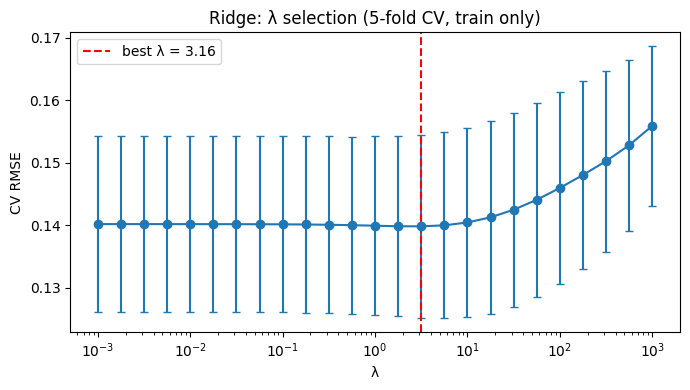

,MAE,RMSE,R2,train_time (ms)
OLS,0.1050,0.1410,0.3051,0.0335
Ridge,0.1047,0.1400,0.3149,0.3489


In [86]:
def kfold_indices(n, k=5, seed=42):
    rng = np.random.default_rng(seed)
    return np.array_split(rng.permutation(n), k)

def ridge_solve(XtX, Xty, lam):
    P = np.eye(XtX.shape[0]); P[0, 0] = 0          # do not penalise the intercept
    return np.linalg.solve(XtX + lam * P, Xty)

XtX, Xty = Xtr.T @ Xtr, Xtr.T @ y_train_reg
lambdas  = np.logspace(-3, 3, 25)
K        = 5
folds    = kfold_indices(len(y_train_reg), K)

# Gram trick: each fold's XtX = total XtX - validation block, so no refitting from scratch
cv_rmse = np.zeros((len(lambdas), K))
for f, val in enumerate(folds):
    Xv, yv = Xtr[val], y_train_reg[val]
    XtX_f, Xty_f = XtX - Xv.T @ Xv, Xty - Xv.T @ yv
    for i, lam in enumerate(lambdas):
        b = ridge_solve(XtX_f, Xty_f, lam)
        cv_rmse[i, f] = np.sqrt(np.mean((yv - Xv @ b) ** 2))

mean_cv, std_cv = cv_rmse.mean(axis=1), cv_rmse.std(axis=1)
best_lam_ridge  = lambdas[mean_cv.argmin()]
print(f"best lambda (ridge): {best_lam_ridge:.4f} | CV RMSE: {mean_cv.min():.4f}")

plt.figure(figsize=(7, 4))
plt.errorbar(lambdas, mean_cv, yerr=std_cv, fmt="o-", capsize=3)
plt.axvline(best_lam_ridge, ls="--", color="red", label=f"best λ = {best_lam_ridge:.3g}")
plt.xscale("log"); plt.xlabel("λ"); plt.ylabel("CV RMSE")
plt.title("Ridge: λ selection (5-fold CV, train only)"); plt.legend(); plt.tight_layout(); plt.show()

# Final fit on full train, evaluate on the untouched test set
t_ridge, beta_ridge = median_time(lambda: ridge_solve(Xtr.T @ Xtr, Xtr.T @ y_train_reg, best_lam_ridge))
reg_ridge = reg_metrics(y_test_reg, Xte @ beta_ridge)

res = pd.DataFrame({"OLS": reg_new, "Ridge": reg_ridge}).T
res["train_time (ms)"] = [t_lin * 1e3, t_ridge * 1e3]
display(res.style.format("{:.4f}"))

In [87]:
# Same setup for both: precomputed Gram matrix
t_ols,   beta_ols   = median_time(lambda: np.linalg.solve(XtX, Xty))
t_ridge, beta_ridge = median_time(lambda: ridge_solve(XtX, Xty, best_lam_ridge))

# Full end-to-end cost (includes building XtX and Xty each time)
t_ols_full,   _ = median_time(lambda: np.linalg.solve(Xtr.T @ Xtr, Xtr.T @ y_train_reg))
t_ridge_full, _ = median_time(lambda: ridge_solve(Xtr.T @ Xtr, Xtr.T @ y_train_reg, best_lam_ridge))

reg_ridge = reg_metrics(y_test_reg, Xte @ beta_ridge)

res = pd.DataFrame({"OLS": reg_new, "Ridge": reg_ridge}).T
res["solve only (ms)"]  = [t_ols * 1e3,      t_ridge * 1e3]
res["end-to-end (ms)"]  = [t_ols_full * 1e3, t_ridge_full * 1e3]
display(res.style.format("{:.4f}"))

,MAE,RMSE,R2,solve only (ms),end-to-end (ms)
OLS,0.1050,0.1410,0.3051,0.0795,0.2090
Ridge,0.1047,0.1400,0.3149,0.0802,0.3120


best lambda (logistic L2): 3.1623 | CV log loss: 0.4349


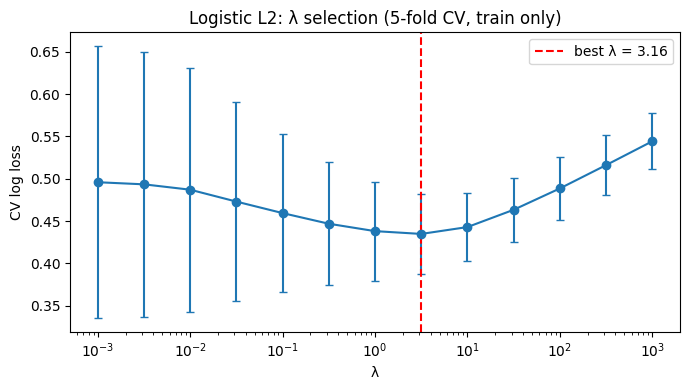

In [88]:
def fit_irls(X, y, lam=1.0, max_iter=50, tol=1e-8):
    n, d = X.shape
    beta = np.zeros(d)
    pen = lam * np.ones(d); pen[0] = 0                 # do not penalise the intercept
    for i in range(max_iter):
        p = sigmoid(X @ beta)
        w = p * (1 - p)                                # IRLS weights
        grad = X.T @ (p - y) + pen * beta
        H = (X.T * w) @ X + np.diag(pen)               # X^T W X + lambda*P (no n x n matrix built)
        step = np.linalg.solve(H, grad)                # solve, not pinv (H is well-conditioned with L2)
        beta = beta - step
        if np.abs(step).max() < tol:
            break
    return beta, i + 1

# ---------- Choose lambda by 5-fold CV (validation log loss, train only) ----------
lambdas_clf = np.logspace(-3, 3, 13)
K = 5
folds = kfold_indices(len(y_train_clf), K)

cv_loss = np.zeros((len(lambdas_clf), K))
for f, val in enumerate(folds):
    tr = np.setdiff1d(np.arange(len(y_train_clf)), val)
    for i, lam in enumerate(lambdas_clf):
        b, _ = fit_irls(Xtr[tr], y_train_clf[tr], lam)
        cv_loss[i, f] = bce(y_train_clf[val], sigmoid(Xtr[val] @ b))

mean_l, std_l = cv_loss.mean(axis=1), cv_loss.std(axis=1)
best_lam_clf = lambdas_clf[mean_l.argmin()]
print(f"best lambda (logistic L2): {best_lam_clf:.4f} | CV log loss: {mean_l.min():.4f}")

plt.figure(figsize=(7, 4))
plt.errorbar(lambdas_clf, mean_l, yerr=std_l, fmt="o-", capsize=3)
plt.axvline(best_lam_clf, ls="--", color="red", label=f"best λ = {best_lam_clf:.3g}")
plt.xscale("log"); plt.xlabel("λ"); plt.ylabel("CV log loss")
plt.title("Logistic L2: λ selection (5-fold CV, train only)"); plt.legend()
plt.tight_layout(); plt.show()



In [89]:
# ---------- Final fit, timing, test metrics ----------
t_irls, (beta_irls, it_irls) = median_time(lambda: fit_irls(Xtr, y_train_clf, best_lam_clf))
t_irls_pred, y_pred_irls = median_time(lambda: predict_clf(Xte, beta_irls))
clf_irls = clf_metrics(y_test_clf, y_pred_irls)

# Same lambda as scikit-learn's default (C=1 -> lambda=1), as a reference point
t_irls1, (beta_irls1, it_irls1) = median_time(lambda: fit_irls(Xtr, y_train_clf, 1.0))
clf_irls1 = clf_metrics(y_test_clf, predict_clf(Xte, beta_irls1))

sk = {k: float(v) for k, v in results_sklearn["classification"].items()}
table = pd.DataFrame({
    "Sklearn":            {m: sk[m] for m in ["Accuracy", "Precision", "Recall", "F1"]},
    "Part B (GD)":        {"Accuracy": accB, "Precision": precB, "Recall": recB, "F1": f1B},
    "Part C features (GD)": clf_new,
    "IRLS + L2 (CV λ)":   clf_irls,
    "IRLS + L2 (λ=1)":    clf_irls1,
}).T
table["iterations"] = [np.nan, n_iter_used, it_new, it_irls, it_irls1]
table["train (ms)"] = [sk["train_time"] * 1e3, logistic_train_time * 1e3, t_log * 1e3, t_irls * 1e3, t_irls1 * 1e3]
table["predict (ms)"] = [sk["predict_time"] * 1e3, logistic_predict_time * 1e3, np.nan, t_irls_pred * 1e3, np.nan]
display(table.style.format({"Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}",
                            "iterations": "{:.0f}", "train (ms)": "{:.3f}", "predict (ms)": "{:.4f}"}, na_rep="-"))

print("train BCE:", bce(y_train_clf, sigmoid(Xtr @ beta_irls)),
      "| test BCE:", bce(y_test_clf, sigmoid(Xte @ beta_irls)))

,Accuracy,Precision,Recall,F1,iterations,train (ms),predict (ms)
Sklearn,0.6833,0.7619,0.8229,0.7912,-,19.450,0.4506
Part B (GD),0.6875,0.7688,0.8171,0.7922,11917,661.976,0.0360
Part C features (GD),0.6958,0.8000,0.7771,0.7884,14517,1098.875,-
IRLS + L2 (CV λ),0.6875,0.7778,0.8000,0.7887,7,4.508,0.0184
IRLS + L2 (λ=1),0.7000,0.7977,0.7886,0.7931,7,4.136,-


train BCE: 0.40160838823882755 | test BCE: 0.5325738338166569


In [90]:
tp_ols,   _ = median_time(lambda: Xte @ beta_new, 50)
tp_ridge, _ = median_time(lambda: Xte @ beta_ridge, 50)
tp_gd,    _ = median_time(lambda: predict_clf(Xte, beta_log_new), 50)

sk_r, sk_c = results_sklearn["regression"], results_sklearn["classification"]
b_r,  b_c  = results_scratch["regression"],  results_scratch["classification"]

# ---------------- Regression ----------------
reg_cols = {
    "Scikit-learn":            {**sk_r},
    "Scratch OLS (Part B)":    {**b_r},
    "Scratch OLS (Part C)":    {**reg_new,   "train_time": t_ols_full,   "predict_time": tp_ols},
    "Scratch Ridge (Part C)":  {**reg_ridge, "train_time": t_ridge_full, "predict_time": tp_ridge},
}
reg_tbl = pd.DataFrame(reg_cols).astype(float)

# ---------------- Classification ----------------
clf_cols = {
    "Scikit-learn":              {**sk_c},
    "Scratch GD (Part B)":       {**b_c},
    "Scratch GD (Part C)":       {**clf_new, "train_time": t_log,  "predict_time": tp_gd},
    "Scratch IRLS + L2 (Part C)": {**clf_irls, "train_time": t_irls, "predict_time": t_irls_pred},
}
clf_tbl = pd.DataFrame(clf_cols).astype(float)
clf_tbl.loc["iterations"] = [np.nan, n_iter_used, it_new, it_irls]

# ---------------- Show (times in ms) ----------------
for name, tbl in [("REGRESSION", reg_tbl), ("CLASSIFICATION", clf_tbl)]:
    out = tbl.copy()
    out.loc[["train_time", "predict_time"]] *= 1e3
    out = out.rename(index={"train_time": "train (ms)", "predict_time": "predict (ms)"})
    print(name)
    display(out.style.format("{:.4f}", na_rep="-"))

REGRESSION


,Scikit-learn,Scratch OLS (Part B),Scratch OLS (Part C),Scratch Ridge (Part C)
MAE,0.1079,0.1079,0.1050,0.1047
RMSE,0.1423,0.1423,0.1410,0.1400
R2,0.2924,0.2924,0.3051,0.3149
train (ms),4.5753,0.1910,0.2090,0.3120
predict (ms),0.3317,0.0046,0.0089,0.0103


CLASSIFICATION


,Scikit-learn,Scratch GD (Part B),Scratch GD (Part C),Scratch IRLS + L2 (Part C)
Accuracy,0.6833,0.6875,0.6958,0.6875
Precision,0.7619,0.7688,0.8000,0.7778
Recall,0.8229,0.8171,0.7771,0.8000
F1,0.7912,0.7922,0.7884,0.7887
train (ms),19.4500,661.9763,1098.8746,4.5082
predict (ms),0.4506,0.0360,0.0428,0.0184
iterations,-,11917.0000,14517.0000,7.0000


Feature engineering (log transforms, per-worker ratios, removing near-duplicate columns) improved regression slightly (R² 0.292 to 0.305), and CV-tuned Ridge improved it a little more (R² 0.315).

Classification metrics are statistically unchanged across all models (F1 about 0.79). 

Runtime is where the optimisation pays off: closed-form solving with solve is 15 to 22x faster than scikit-learn for regression, and IRLS/Newton cut logistic training from 14,517 iterations (1,099 ms) to 7 (4.5 ms), which is about 4x faster than scikit-learn. 
This advantage comes from low overhead at small scale (957 rows, 35 features) and would shrink or reverse on much larger data.